In [1]:
import pandas as pd

In [2]:
df = pd.read_excel(r"C:\Users\HP\Documents\AI_Retail_Intelligence_Project\Superstore_sales.xlsx")

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium,2011


In [7]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("RagavanSangeetha@0930")
host = "localhost"
port = "3306"
database = "retail_intelligence"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

In [9]:
df.to_sql(
    "retail_intelligence",
    con=engine,
    if_exists="replace",
    index=False
)

51290

ETL Pipeline

In [10]:
import pandas as pd
df = pd.read_excel(r"C:\Users\HP\Documents\AI_Retail_Intelligence_Project\Superstore_sales.xlsx")
df.shape

(51290, 21)

In [11]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

In [14]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

In [15]:
df[["sales", "quantity", "discount", "profit", "shipping_cost"]].describe()

,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.641740,26.375818
std,487.565361,2.278766,0.212280,174.424113,57.296810
min,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,30.758625,2.000000,0.000000,0.000000,2.610000
50%,85.053000,3.000000,0.000000,9.240000,7.790000
75%,251.053200,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  float64       
 15  qu

In [20]:
df.to_excel(
    r"C:\Users\HP\Documents\AI_Retail_Intelligence_Project\superstore_sales_cleaned.xlsx",
    index=False
)

In [21]:
df.to_sql(
    "superstore_sales_cleaned",
    con=engine,
    if_exists="replace",
    index=False
)

51290

EDA & Data Visualization

In [22]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.490581,3.476545,0.142908,28.641740,26.375818,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.002000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,30.758625,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.053000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.053200,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.565361,2.278766,0.212280,174.424113,57.296810,1.098931


In [24]:
df.nunique()

order_id          25035
order_date         1430
ship_date          1464
ship_mode             4
customer_name       795
segment               3
state              1094
country             147
market                7
region               13
product_id        10292
category              3
sub_category         17
product_name       3788
sales             27200
quantity             14
discount             29
profit            28234
shipping_cost     17095
order_priority        4
year                  4
dtype: int64

In [25]:
df["category"].value_counts()

category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

In [26]:
df.groupby("category")[["sales","profit"]].sum()

,sales,profit
category,,
Furniture,4.110874e+06,286782.25380
Office Supplies,3.787070e+06,518473.83430
Technology,4.744557e+06,663778.73318


In [27]:
df.groupby("sub_category")[["sales", "profit"]].sum().sort_values(
    "sales", ascending=False
)

,sales,profit
sub_category,,
Phones,1.706824e+06,216717.00580
Copiers,1.509436e+06,258567.54818
Chairs,1.501682e+06,141973.79750
Bookcases,1.466572e+06,161924.41950
Storage,1.127086e+06,108461.48980
Appliances,1.011064e+06,141680.58940
Machines,7.790601e+05,58867.87300
Tables,7.570419e+05,-64083.38870
Accessories,7.492370e+05,129626.30620


In [28]:
df.groupby("region")[["sales", "profit"]].sum().sort_values(
    "sales", ascending=False
)

,sales,profit
region,,
Central,2.822303e+06,311403.98164
South,1.600907e+06,140355.76618
North,1.248166e+06,194597.95252
Oceania,1.100185e+06,121666.64200
Southeast Asia,8.844232e+05,17852.32900
North Asia,8.483098e+05,165578.42100
EMEA,8.061613e+05,43897.97100
Africa,7.837732e+05,88871.63100
Central Asia,7.528266e+05,132480.18700


In [29]:
df.groupby("market")[["sales", "profit"]].sum().sort_values(
    "sales", ascending=False
)

,sales,profit
market,,
APAC,3.585744e+06,437577.57900
EU,2.938089e+06,372829.74150
US,2.297201e+06,286397.02170
LATAM,2.164605e+06,221643.48708
EMEA,8.061613e+05,43897.97100
Africa,7.837732e+05,88871.63100
Canada,6.692817e+04,17817.39000


In [30]:
df.groupby("segment")[["sales", "profit"]].sum().sort_values(
    "sales", ascending=False
)

,sales,profit
segment,,
Consumer,6.507949e+06,749239.78206
Corporate,3.824698e+06,442785.85866
Home Office,2.309855e+06,277009.18056


In [31]:
df.groupby("year")[["sales", "profit"]].sum()

,sales,profit
year,,
2011,2.259451e+06,248940.81154
2012,2.677439e+06,307415.27910
2013,3.405746e+06,408512.76018
2014,4.299866e+06,504165.97046


In [32]:
df["month"] = df["order_date"].dt.month

df.groupby("month")[["sales", "profit"]].sum()

,sales,profit
month,,
1,6.751337e+05,73535.38454
2,5.437394e+05,72509.72922
3,7.705009e+05,94087.52096
4,6.985612e+05,73513.63124
5,9.040123e+05,104509.78428
6,1.269717e+06,147079.41684
7,7.493818e+05,78070.09172
8,1.293833e+06,151854.10972
9,1.437380e+06,170438.18316


In [33]:
df.groupby("discount")[["sales", "profit"]].sum().sort_index()

,sales,profit
discount,,
0.000,6.992411e+06,1.770695e+06
0.002,2.613956e+05,5.797658e+04
0.070,1.216169e+05,2.114850e+04
0.100,1.579606e+06,2.606417e+05
0.150,2.838799e+05,2.609656e+04
0.150,2.214999e+04,1.279348e+03
0.170,2.473992e+05,2.816307e+04
0.200,1.203832e+06,1.177159e+05
0.202,1.621565e+04,-5.952727e+02


In [34]:
df.groupby("product_name")["sales"].sum().sort_values(
    ascending=False
).head(10)

product_name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: sales, dtype: float64

In [35]:
df.groupby("product_name")["profit"].sum().sort_values(
    ascending=False
).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: profit, dtype: float64

In [36]:
df[["sales", "quantity", "discount", "profit", "shipping_cost"]].corr()

,sales,quantity,discount,profit,shipping_cost
sales,1.000000,0.313577,-0.086722,0.485939,0.768073
quantity,0.313577,1.000000,-0.019875,0.104743,0.272649
discount,-0.086722,-0.019875,1.000000,-0.316375,-0.079055
profit,0.485939,0.104743,-0.316375,1.000000,0.357033
shipping_cost,0.768073,0.272649,-0.079055,0.357033,1.000000


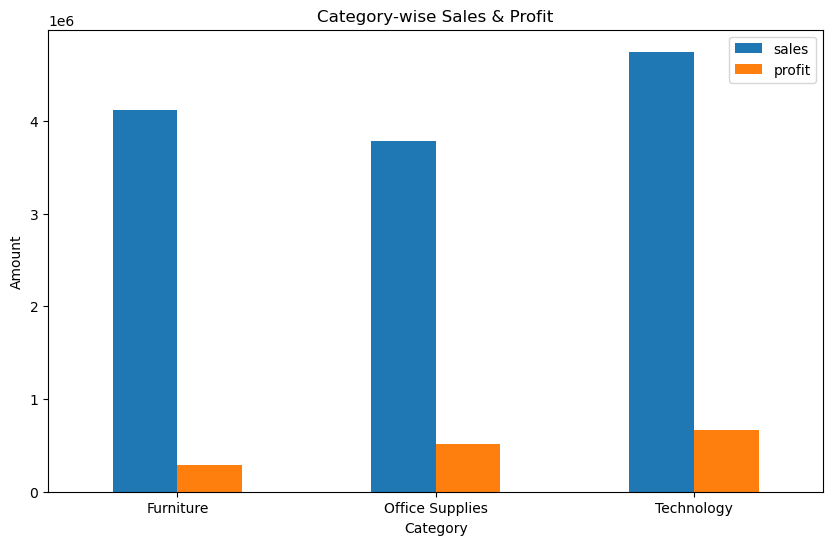

In [37]:
import matplotlib.pyplot as plt

df.groupby("category")[["sales", "profit"]].sum().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Category-wise Sales & Profit")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

RFM Customer Segmentation

In [38]:
rfm = df.groupby("customer_name").agg(
    Recency=("order_date", lambda x: (df["order_date"].max() - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("sales", "sum")
).reset_index()

rfm.head()

,customer_name,Recency,Frequency,Monetary
0,Aaron Bergman,16,37,24644.62750
1,Aaron Hawkins,12,34,20759.51384
2,Aaron Smayling,23,31,14212.62840
3,Adam Bellavance,35,41,20186.77840
4,Adam Hart,2,42,21718.20142


In [39]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,customer_name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,Aaron Bergman,16,37,24644.62750,3,4,5
1,Aaron Hawkins,12,34,20759.51384,4,3,5
2,Aaron Smayling,23,31,14212.62840,2,2,3
3,Adam Bellavance,35,41,20186.77840,2,5,5
4,Adam Hart,2,42,21718.20142,5,5,5


In [40]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm["Segment"] = rfm["RFM_Score"].apply(
    lambda x: (
        "Champions" if x in ["555", "554", "545", "455"]
        else "Loyal Customers" if x[1] in ["4", "5"]
        else "Potential Loyalists" if x[1] in ["2", "3"]
        else "At Risk" if x[0] in ["1", "2"]
        else "Others"
    )
)

rfm.head()

,customer_name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,Aaron Bergman,16,37,24644.62750,3,4,5,345,Loyal Customers
1,Aaron Hawkins,12,34,20759.51384,4,3,5,435,Potential Loyalists
2,Aaron Smayling,23,31,14212.62840,2,2,3,223,Potential Loyalists
3,Adam Bellavance,35,41,20186.77840,2,5,5,255,Loyal Customers
4,Adam Hart,2,42,21718.20142,5,5,5,555,Champions


In [41]:
rfm["Segment"].value_counts()

Segment
Potential Loyalists    318
Loyal Customers        264
Others                  87
At Risk                 72
Champions               54
Name: count, dtype: int64

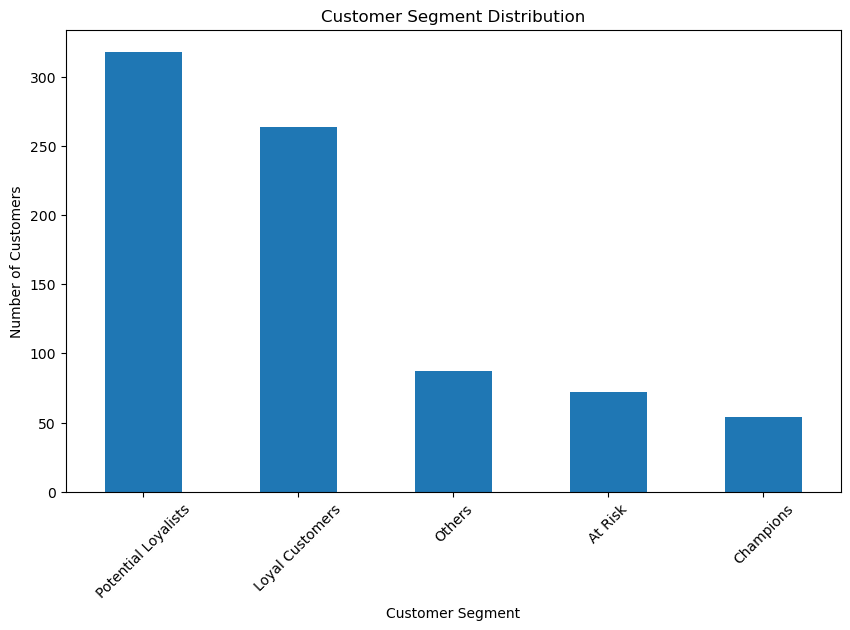

In [42]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [43]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,53.14,25.36,12471.83
Champions,4.07,39.69,23323.47
Loyal Customers,21.64,37.33,17499.38
Others,10.25,24.97,12101.10
Potential Loyalists,24.92,30.68,15133.43


K Means Clustering

In [44]:
from sklearn.preprocessing import StandardScaler

features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

rfm_scaled[:5]

array([[-0.26872125,  0.8523629 ,  1.67906462],
       [-0.41459588,  0.29723305,  0.93286521],
       [-0.01344065, -0.2578968 , -0.32457087],
       [ 0.42418324,  1.59253603,  0.82286203],
       [-0.77928245,  1.77757931,  1.11699678]])

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled[:5]

array([[-0.26872125,  0.8523629 ,  1.67906462],
       [-0.41459588,  0.29723305,  0.93286521],
       [-0.01344065, -0.2578968 , -0.32457087],
       [ 0.42418324,  1.59253603,  0.82286203],
       [-0.77928245,  1.77757931,  1.11699678]])

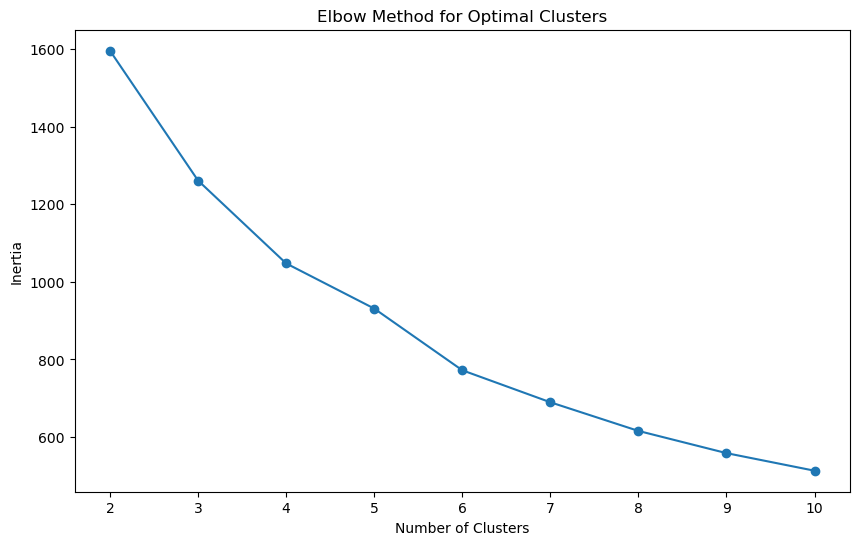

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,customer_name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
0,Aaron Bergman,16,37,24644.62750,3,4,5,345,Loyal Customers,2
1,Aaron Hawkins,12,34,20759.51384,4,3,5,435,Potential Loyalists,2
2,Aaron Smayling,23,31,14212.62840,2,2,3,223,Potential Loyalists,1
3,Adam Bellavance,35,41,20186.77840,2,5,5,255,Loyal Customers,2
4,Adam Hart,2,42,21718.20142,5,5,5,555,Champions,2


In [48]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,102.60,29.40,14090.07
1,17.27,34.32,15297.63
2,17.87,37.54,23100.61
3,21.69,27.07,12025.38


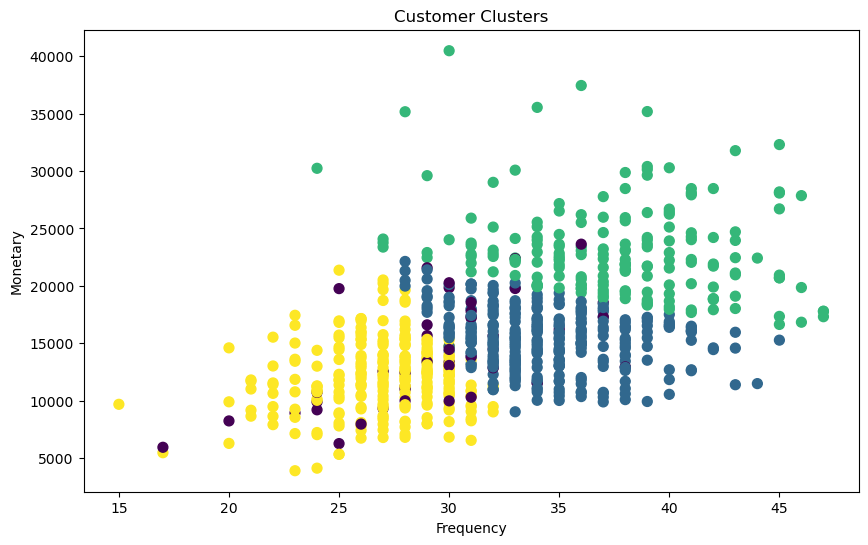

In [49]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    s=50
)

plt.title("Customer Clusters")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

Sales Forecasting / Machine Learning

In [50]:
sales_data = df[["order_date", "sales"]].copy()

sales_data.head()

,order_date,sales
0,2011-01-01,408.300
1,2011-01-01,120.366
2,2011-01-01,66.120
3,2011-01-01,44.865
4,2011-01-01,113.670


In [51]:
monthly_sales = (
    sales_data
    .set_index("order_date")
    .resample("ME")["sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,order_date,sales
0,2011-01-31,98898.48886
1,2011-02-28,91152.15698
2,2011-03-31,145729.36736
3,2011-04-30,116915.76418
4,2011-05-31,146747.83610


In [52]:
monthly_sales["year"] = monthly_sales["order_date"].dt.year
monthly_sales["month"] = monthly_sales["order_date"].dt.month
monthly_sales["time_index"] = range(len(monthly_sales))

monthly_sales.head()

,order_date,sales,year,month,time_index
0,2011-01-31,98898.48886,2011,1,0
1,2011-02-28,91152.15698,2011,2,1
2,2011-03-31,145729.36736,2011,3,2
3,2011-04-30,116915.76418,2011,4,3
4,2011-05-31,146747.83610,2011,5,4


In [53]:
from sklearn.ensemble import RandomForestRegressor

X = monthly_sales[["year", "month", "time_index"]]
y = monthly_sales["sales"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
future_dates = pd.date_range(
    start=monthly_sales["order_date"].max() + pd.offsets.MonthEnd(1),
    periods=12,
    freq="ME"
)

future_data = pd.DataFrame({
    "order_date": future_dates
})

future_data["year"] = future_data["order_date"].dt.year
future_data["month"] = future_data["order_date"].dt.month
future_data["time_index"] = range(
    len(monthly_sales),
    len(monthly_sales) + 12
)

future_data["Predicted_Sales"] = model.predict(
    future_data[["year", "month", "time_index"]]
)

future_data

,order_date,year,month,time_index,Predicted_Sales
0,2015-01-31,2015,1,48,364855.436630
1,2015-02-28,2015,2,49,360761.767105
2,2015-03-31,2015,3,50,374057.937963
3,2015-04-30,2015,4,51,376030.652473
4,2015-05-31,2015,5,52,394221.631750
5,2015-06-30,2015,6,53,432486.537805
6,2015-07-31,2015,7,54,420774.659786
7,2015-08-31,2015,8,55,472104.695388
8,2015-09-30,2015,9,56,492465.634232
9,2015-10-31,2015,10,57,485959.141018


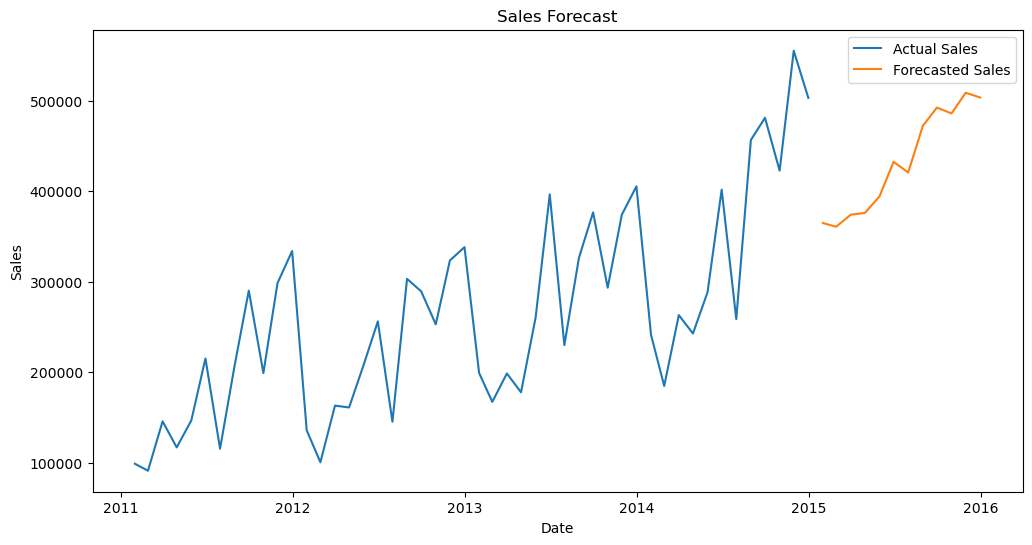

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"],
    label="Actual Sales"
)

plt.plot(
    future_data["order_date"],
    future_data["Predicted_Sales"],
    label="Forecasted Sales"
)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()